<a href="https://colab.research.google.com/github/nagasumukh01/FUTURE_ML_2/blob/main/FUTURE_ML_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import necessary libraries

In [ ]:
import pandas as pd
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns

# Download necessary NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("Libraries imported and NLTK data downloaded successfully.")

Libraries imported and NLTK data downloaded successfully.


## 2. Load and explore the dataset

In [ ]:
df = pd.read_csv('/content/customer_support_tickets.csv')

print("First 5 rows of the dataset:")
display(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDataFrame information:")
df.info()

First 5 rows of the dataset:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0



Missing values per column:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name    

## 3. Preprocess text: cleaning, tokenization, stopword removal, lemmatization

In [ ]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize text
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize words
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join words back into a single string
    return ' '.join(tokens)

# Apply the preprocessing function to the 'Ticket Description' column
df['processed_description'] = df['Ticket Description'].apply(preprocess_text)

# Display the first few rows with original and processed descriptions
print(df[['Ticket Description', 'processed_description']].head())

                                  Ticket Description  \
0  I'm having an issue with the {product_purchase...   
1  I'm having an issue with the {product_purchase...   
2  I'm facing a problem with my {product_purchase...   
3  I'm having an issue with the {product_purchase...   
4  I'm having an issue with the {product_purchase...   

                               processed_description  
0  im issue productpurchased please assist billin...  
1  im issue productpurchased please assist need c...  
2  im facing problem productpurchased productpurc...  
3  im issue productpurchased please assist proble...  
4  im issue productpurchased please assist note s...  


## 4. Feature extraction (TF-IDF Vectorizer)

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X = tfidf_vectorizer.fit_transform(df['processed_description'])

print("Shape of TF-IDF matrix (X):")
print(X.shape)

Shape of TF-IDF matrix (X):
(8469, 5000)


## 5. Split data into train/test

In [ ]:
y_category = df['Ticket Type']
y_priority = df['Ticket Priority']

# Split data for category classification
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X, y_category, test_size=0.2, random_state=42, stratify=y_category)

# Split data for priority classification
X_train_prio, X_test_prio, y_train_prio, y_test_prio = train_test_split(X, y_priority, test_size=0.2, random_state=42, stratify=y_priority)

print("Shape of training and testing sets for Category Classification:")
print(f"X_train_cat: {X_train_cat.shape}, y_train_cat: {y_train_cat.shape}")
print(f"X_test_cat: {X_test_cat.shape}, y_test_cat: {y_test_cat.shape}")

print("\nShape of training and testing sets for Priority Classification:")
print(f"X_train_prio: {X_train_prio.shape}, y_train_prio: {y_train_prio.shape}")
print(f"X_test_prio: {X_test_prio.shape}, y_test_prio: {y_test_prio.shape}")

Shape of training and testing sets for Category Classification:
X_train_cat: (6775, 5000), y_train_cat: (6775,)
X_test_cat: (1694, 5000), y_test_cat: (1694,)

Shape of training and testing sets for Priority Classification:
X_train_prio: (6775, 5000), y_train_prio: (6775,)
X_test_prio: (1694, 5000), y_test_prio: (1694,)


## 6. Train separate models: one for category classification, one for priority classification

In [ ]:
category_model = RandomForestClassifier(random_state=42)
category_model.fit(X_train_cat, y_train_cat)
y_pred_cat = category_model.predict(X_test_cat)

priority_model = RandomForestClassifier(random_state=42)
priority_model.fit(X_train_prio, y_train_prio)
y_pred_prio = priority_model.predict(X_test_prio)

print("Category and Priority classification models trained and predictions made.")

Category and Priority classification models trained and predictions made.


## 7. Evaluate models with metrics and visualizations


--- Category Classification Model Evaluation ---
Accuracy (Category): 0.19952774498229045
Classification Report (Category):
                       precision    recall  f1-score   support

     Billing inquiry       0.17      0.16      0.16       327
Cancellation request       0.22      0.23      0.22       339
     Product inquiry       0.19      0.19      0.19       328
      Refund request       0.21      0.20      0.20       351
     Technical issue       0.21      0.22      0.22       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



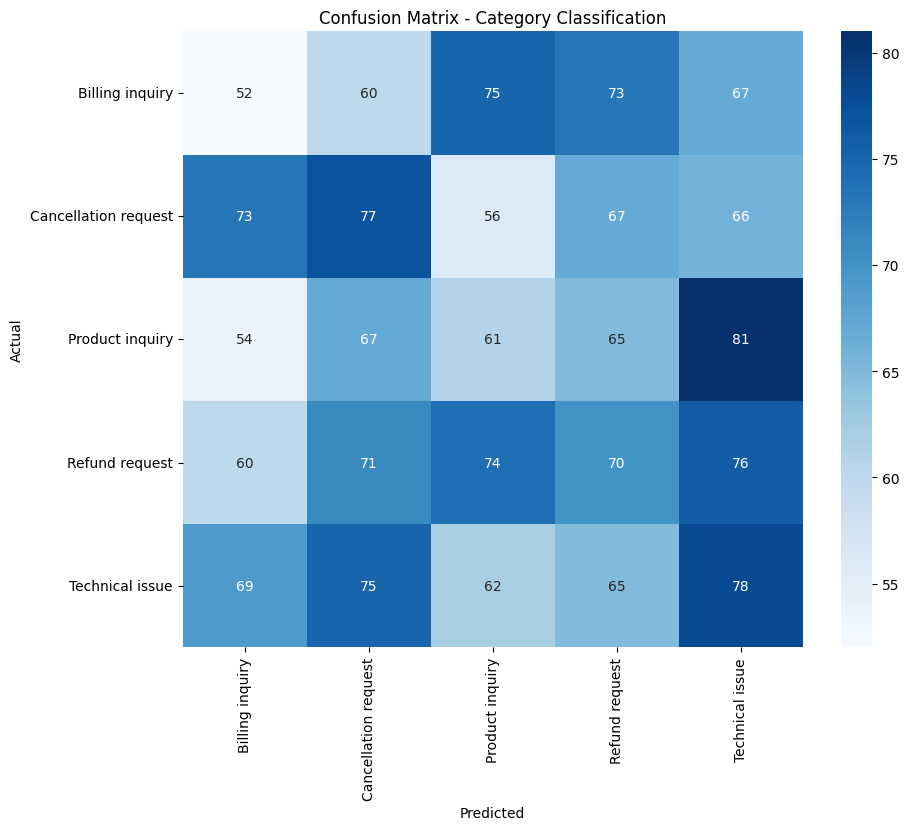


--- Priority Classification Model Evaluation ---
Accuracy (Priority): 0.2644628099173554
Classification Report (Priority):
               precision    recall  f1-score   support

    Critical       0.26      0.28      0.27       426
        High       0.28      0.29      0.28       417
         Low       0.27      0.25      0.26       413
      Medium       0.24      0.24      0.24       438

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.26      1694
weighted avg       0.26      0.26      0.26      1694



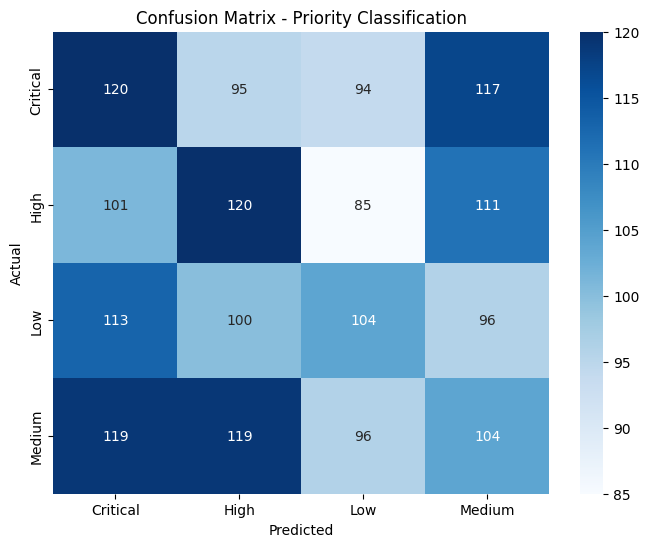

In [ ]:
# Evaluate Category Classification Model
print("\n--- Category Classification Model Evaluation ---")
print("Accuracy (Category):", accuracy_score(y_test_cat, y_pred_cat))
print("Classification Report (Category):\n", classification_report(y_test_cat, y_pred_cat, zero_division=0))

# Confusion Matrix for Category Classification
cm_cat = confusion_matrix(y_test_cat, y_pred_cat)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues',
            xticklabels=category_model.classes_,
            yticklabels=category_model.classes_)
plt.title('Confusion Matrix - Category Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Evaluate Priority Classification Model
print("\n--- Priority Classification Model Evaluation ---")
print("Accuracy (Priority):", accuracy_score(y_test_prio, y_pred_prio))
print("Classification Report (Priority):\n", classification_report(y_test_prio, y_pred_prio, zero_division=0))

# Confusion Matrix for Priority Classification
cm_prio = confusion_matrix(y_test_prio, y_pred_prio)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_prio, annot=True, fmt='d', cmap='Blues',
            xticklabels=priority_model.classes_,
            yticklabels=priority_model.classes_)
plt.title('Confusion Matrix - Priority Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. Add a function to classify and prioritize new ticket text

In [ ]:
def predict_ticket_details(raw_ticket_text):
    # Preprocess the raw ticket text
    processed_text = preprocess_text(raw_ticket_text)

    # Transform the preprocessed text using the fitted TF-IDF vectorizer
    # tfidf_vectorizer.transform expects an iterable, so wrap in a list
    text_features = tfidf_vectorizer.transform([processed_text])

    # Predict category
    predicted_category = category_model.predict(text_features)[0]

    # Predict priority
    predicted_priority = priority_model.predict(text_features)[0]

    return predicted_category, predicted_priority

# Test the function with an example raw ticket description
example_ticket_description = "My printer is not working after the recent software update. It's urgent! I need it fixed immediately."
predicted_category, predicted_priority = predict_ticket_details(example_ticket_description)

print(f"Example Ticket Description: {example_ticket_description}")
print(f"Predicted Category: {predicted_category}")
print(f"Predicted Priority: {predicted_priority}")

Example Ticket Description: My printer is not working after the recent software update. It's urgent! I need it fixed immediately.
Predicted Category: Technical issue
Predicted Priority: Critical
